In [2]:
import pandas as pd
data = pd.read_csv('Mall_Customers.csv')

In [3]:
data.sample(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
92,93,Male,48,60,49
83,84,Female,46,54,44
106,107,Female,66,63,50
82,83,Male,67,54,41
48,49,Female,29,40,42


In [6]:
data = data[['Annual Income (k$)','Spending Score (1-100)']]
data.sample(5)

,Annual Income (k$),Spending Score (1-100)
82,54,41
56,44,50
132,72,34
194,120,16
126,71,35


In [14]:
# clolumns name pahatha paridi wenas kara gatah ahaka

data = data.rename(columns={'Annual Income (k$)': 'income' ,'Spending Score (1-100)' : 'score'})
data.sample(5)

,income,score
56,44,50
37,34,73
83,54,44
199,137,83
117,65,59


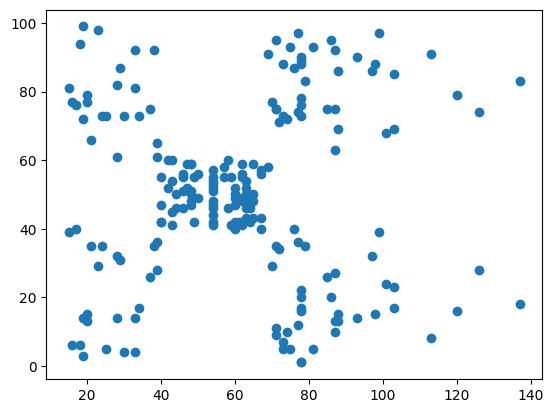

In [10]:
import matplotlib.pyplot as plt
plt.scatter(data['income'],data[''])

In [15]:
# k magin awashya cluster s gana kiyawee, so, pahatha paridi awashya niwaradima clusters gana soya gamu

from sklearn.cluster import KMeans
k_values = [1,2,3,4,5,6,7,8,9,10]
wcss_error = []
for k in k_values:
    model = KMeans(n_clusters = k)
    model.fit(data[['income','score']])
    wcss_error.append(model.inertia_)

In [16]:
wcss_error

[269981.28,
 184102.1534926471,
 106348.37306211122,
 73880.64496247195,
 44448.4554479337,
 38792.367293075135,
 30227.606513152008,
 28414.228348686203,
 22993.54204424098,
 19710.03027166079]

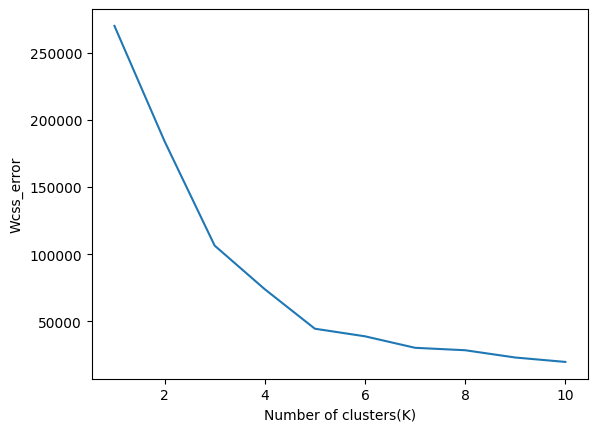

In [18]:
plt.xlabel('Number of clusters(K)')
plt.ylabel('Wcss_error')
plt.plot(k_values,wcss_error)

In [27]:
# anukkramana wenasa wadima wena awasthaawe agaya k lesa ganii.
#k=5 leasa gatha haka

from sklearn.cluster import KMeans
model = KMeans(n_clusters = 5)
pred = model.fit_predict(data)
pred

array([2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4,
       2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 0,
       2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [28]:
data.head(5)

,income,score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [29]:
#clusters tika table eke column ekak lesa damiima

data['cluster'] = pred
data.head(5)

,income,score,cluster
0,15,39,2
1,15,81,4
2,16,6,2
3,16,77,4
4,17,40,2


In [34]:
#clusters tika wena wenama gamu. mulinma cluster eka '0' wena eka gamu

c1 = data[data['cluster']==0]
c2 = data[data['cluster']==1]
c3 = data[data['cluster']==2]
c4 = data[data['cluster']==3]
c5 = data[data['cluster']==4]
c1.head(5)


,income,score,cluster
43,39,61,0
46,40,55,0
47,40,47,0
48,40,42,0
49,40,42,0


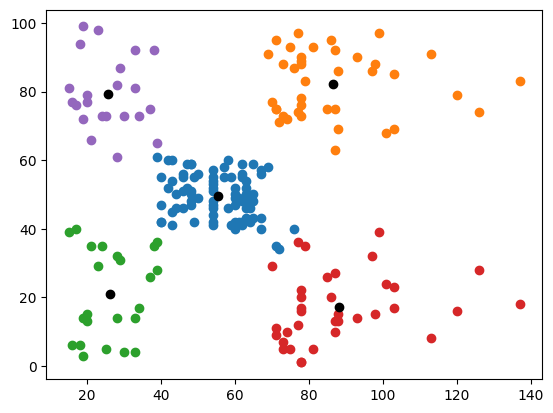

In [40]:
#dan group karapu data tika wena wenama clusters walata penwamu
#clusters wala centers tika bala ganiima

plt.scatter(c1['income'],c1['score'])
plt.scatter(c2['income'],c2['score'])
plt.scatter(c3['income'],c3['score'])
plt.scatter(c4['income'],c4['score'])
plt.scatter(c5['income'],c5['score'])

plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color = 'black')

In [36]:
#clusters wala centers tike agayan bala ganiima

model.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [26.30434783, 20.91304348],
       [88.2       , 17.11428571],
       [25.72727273, 79.36363636]])